# Determination des clusters

In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler

In [13]:
data_file_path = '../data/raw/dataTp2.csv'
if os.path.exists(data_file_path):
    print("File exists : ", data_file_path)

File exists :  ../data/raw/dataTp2.csv


In [14]:
# Chargement des données
data = pd.read_csv(data_file_path)
data.shape

(30000, 7)

In [7]:

# Normalisation des données pour le K-means
#scaler = StandardScaler()
#data_scaled = scaler.fit_transform(data[['valence_intensity', 'fear_intensity', 'anger_intensity', 'happiness_intensity', 'sadness_intensity']])

X = data[['valence_intensity', 'fear_intensity', 'anger_intensity', 'happiness_intensity', 'sadness_intensity']]
y = data['sentiment']

# Initialisation des listes pour stocker les scores
overlap_scores = []
silhouette_scores = []

# Indice d'Overlap
def overlap_score(data, labels):
    clusters = np.unique(labels)
    total_overlap = 0
    for cluster in clusters:
        cluster_points = data[labels == cluster]
        intra_distances = cdist(cluster_points, cluster_points)
        total_overlap += np.sum(intra_distances < 0.5) / (len(cluster_points) * (len(cluster_points) - 1))
    return total_overlap / len(clusters)

# Évaluation pour chaque valeur de K
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=0)
    labels = kmeans.fit_predict(X)
    
    # Score silhouette
    silhouette_avg = silhouette_score(X, labels)
    silhouette_scores.append(silhouette_avg)
    
    # Overlap
    overlap_avg = overlap_score(X, labels)
    overlap_scores.append(overlap_avg)

# Print des résultats dans un tableau
results = pd.DataFrame({
    'K': range(2, 11),
    'Overlap Score': overlap_scores,
    'Silhouette Score': silhouette_scores
})
print("Résultats d'Overlap et de Silhouette pour chaque K:\n", results)

# Les valeurs optimales de K
optimal_k_overlap = results['K'][results['Overlap Score'].idxmin()]
optimal_k_silhouette = results['K'][results['Silhouette Score'].idxmax()]
print(f"Nombre optimal de clusters selon Overlap : {optimal_k_overlap}")
print(f"Nombre optimal de clusters selon Silhouette : {optimal_k_silhouette}")

# Évaluation pour K = 3 et les valeurs optimales
eval_ks = [3, optimal_k_overlap, optimal_k_silhouette]
sentiments = data['sentiment'] 

for k in eval_ks:
    kmeans = KMeans(n_clusters=k, random_state=0)
    predicted_labels = kmeans.fit_predict(X)
    
    # Mapping des clusters aux sentiments pour l'évaluation
    sentiment_labels = pd.Series(sentiments).map({-1: 0, 0: 1, 1: 2})  # Mapping des sentiments pour comparer les classes
    
    # Calcul des scores
    precision = precision_score(sentiment_labels, predicted_labels, average='weighted')
    recall = recall_score(sentiment_labels, predicted_labels, average='weighted')
    f1 = f1_score(sentiment_labels, predicted_labels, average='weighted')
    
    print(f"\nÉvaluation pour K = {k}")
    print(f"Précision: {precision:.2f}, Rappel: {recall:.2f}, F1-Score: {f1:.2f}")

Résultats d'Overlap et de Silhouette pour chaque K:
     K  Overlap Score  Silhouette Score
0   2       0.996768          0.429862
1   3       0.999091          0.342330
2   4       0.999836          0.288323
3   5       1.000187          0.261272
4   6       1.000217          0.227486
5   7       1.000311          0.211747
6   8       1.000391          0.195900
7   9       1.000412          0.194996
8  10       1.000482          0.194978
Nombre optimal de clusters selon Overlap : 2
Nombre optimal de clusters selon Silhouette : 2

Évaluation pour K = 3
Précision: 0.34, Rappel: 0.24, F1-Score: 0.27

Évaluation pour K = 2
Précision: 0.45, Rappel: 0.60, F1-Score: 0.50

Évaluation pour K = 2
Précision: 0.45, Rappel: 0.60, F1-Score: 0.50


c:\Users\Jordan Frantz\anaconda3\envs\IFT799_Env\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Jordan Frantz\anaconda3\envs\IFT799_Env\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [17]:
# Séparation des caractéristiques et du sentiment associé
X = data[['valence_intensity', 'fear_intensity', 'anger_intensity', 'happiness_intensity', 'sadness_intensity']]
y = data['sentiment']

# K-means pour K = 3
K = 3
kmeans = KMeans(n_clusters=K, random_state=42)
clusters = kmeans.fit_predict(X)


c:\Users\Jordan Frantz\anaconda3\envs\IFT799_Env\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


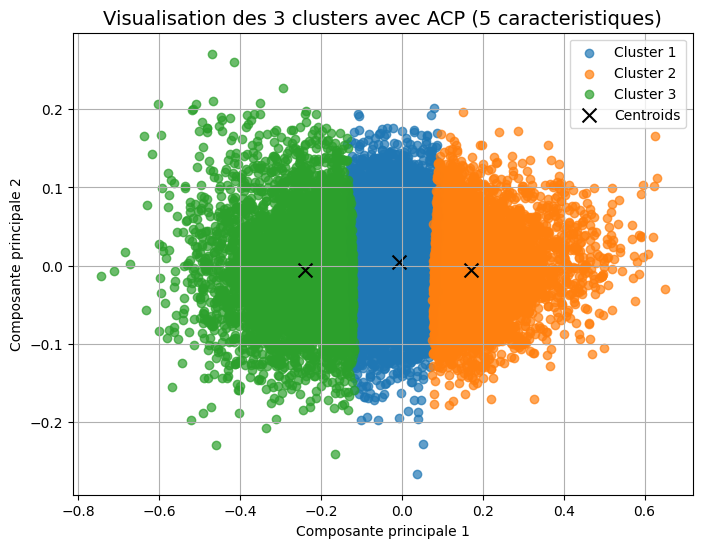

In [18]:
# Réduction de la dimensionnalité avec PCA (2 composantes principales)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

centroids_pca = pca.transform(kmeans.cluster_centers_) # Transformer les centroïdes avec PCA

# Visualisation des clusters
plt.figure(figsize=(8, 6))
for cluster_id in range(3):
    plt.scatter(
        X_pca[clusters == cluster_id, 0],  # Première composante principale
        X_pca[clusters == cluster_id, 1],  # Deuxième composante principale
        label=f"Cluster {cluster_id + 1}",
        alpha=0.7
    )
# Print les centroïdes
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], color='black', marker='x', s=100, label='Centroids')

plt.title('Visualisation des 3 clusters avec ACP (5 caracteristiques)', fontsize=14)
plt.xlabel('Composante principale 1')
plt.ylabel('Composante principale 2')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# Calcul du score silhouette
silhouette_avg = silhouette_score(X, clusters , metric="euclidean")
print(f"Score de silhouette pour K={K}: {silhouette_avg}")

Score de silhouette pour K=3: 0.34234122643618004


In [20]:
# Calcul de l'Overlap
def overlap_score(X, labels, centroids):
    distances = cdist(X, centroids, 'euclidean')
    min_distances = np.min(distances, axis=1)
    intra_cluster_variance = np.mean(min_distances)
    return intra_cluster_variance

In [21]:
centroids = kmeans.cluster_centers_
overlap_score_value = overlap_score(X.values, clusters, centroids)
print(f"Score d'Overlap pour K={K}: {overlap_score_value}")

Score d'Overlap pour K=3: 0.09313603667512249


In [22]:
# Mapping de chaque cluster à la classe de sentiment dominante dans ce cluster
def map_clusters_to_sentiment(clusters, true_labels):
    # On trouve la classe majoritaire pour chaque cluster et on converti les labels en valeurs positives 
    shifted_labels = true_labels + 1
    mapping = {}
    for cluster in np.unique(clusters):
        # Les vrais labels associés à ce cluster
        true_labels_in_cluster = shifted_labels[clusters == cluster]
        majority_label = np.bincount(true_labels_in_cluster).argmax() # Determiner la classe majoritaire
        mapping[cluster] = majority_label
    # Les labels prédits basés sur le mapping et retour aux valeurs originales
    predicted_labels_shifted = np.vectorize(mapping.get)(clusters)
    predicted_labels = predicted_labels_shifted - 1
    return predicted_labels

In [23]:
results= map_clusters_to_sentiment(clusters, y.values)
print(np.unique(results))

unique_elements, counts = np.unique(results, return_counts=True)

# Print des résultats
for element, count in zip(unique_elements, counts):
    print(f"Élément: {element}, Occurrences: {count}")

[-1  0  1]
Élément: -1, Occurrences: 5806
Élément: 0, Occurrences: 15452
Élément: 1, Occurrences: 8742


In [24]:
# Mapping des clusters aux sentiments
y_pred = map_clusters_to_sentiment(clusters, y.values)

# Calcul de la précision, le rappel et le F1-score
precision = precision_score(y, y_pred, average='macro')
recall = recall_score(y, y_pred, average='macro')
f1 = f1_score(y, y_pred, average='macro')

print(f"Précision pour K={K}: {precision}")
print(f"Rappel pour K={K}: {recall}")
print(f"F1-score pour K={K}: {f1}")

Précision pour K=3: 0.7559500683725785
Rappel pour K=3: 0.7101666666666665
F1-score pour K=3: 0.7054075570893366


# Evaluation du clustering

In [25]:
from sklearn.metrics import confusion_matrix, classification_report

# Mapping des clusters aux sentiments (étiquettes originales)
results = map_clusters_to_sentiment(clusters, y.values)

# Matrice de confusion
conf_matrix = confusion_matrix(y, results)

print("Matrice de confusion :")
print(conf_matrix)

# Rapport de classification (Précision, Rappel, F1-Score)
classification_report_str = classification_report(y, results, target_names=["Sentiment -1 (négatif)", "Sentiment 0 (neutre)", "Sentiment 1 (positif)"])

print("\nRapport de classification :")
print(classification_report_str)


Matrice de confusion :
[[4748 5194   58]
 [   1 8936 1063]
 [1057 1322 7621]]

Rapport de classification :
                        precision    recall  f1-score   support

Sentiment -1 (négatif)       0.82      0.47      0.60     10000
  Sentiment 0 (neutre)       0.58      0.89      0.70     10000
 Sentiment 1 (positif)       0.87      0.76      0.81     10000

              accuracy                           0.71     30000
             macro avg       0.76      0.71      0.71     30000
          weighted avg       0.76      0.71      0.71     30000



# Dertermination des clusters avec les sous-ensembles de 4 features

In [ ]:
import itertools


K_values = range(2, 11) # Valeurs possibles de K

results = []   # Les résultats pour chaque sous-ensemble

# Itération sur les combinaisons possibles
for subset in itertools.combinations(X.columns, 4):
    X_subset = X[list(subset)]
    silhouette_scores = []
    overlap_scores = []
    
    print(f"Analyse du sous-ensemble d'attributs : {subset}")
    
    # Test de chaque valeur de K pour chaque sous-ensemble 
    for K in K_values:
        # K-means
        kmeans = KMeans(n_clusters=K, random_state=42)
        clusters = kmeans.fit_predict(X_subset)
        
        # Calcul du score silhouette
        silhouette_avg = silhouette_score(X_subset, clusters)
        silhouette_scores.append(silhouette_avg)
        
        # Calcul de d'Overlap
        overlap_score_value = overlap_score(X_subset.values, clusters, kmeans.cluster_centers_)
        overlap_scores.append(overlap_score_value)
    
    # K optimal pour chaque critère
    optimal_k_silhouette = K_values[np.argmax(silhouette_scores)]
    optimal_k_overlap = K_values[np.argmin(overlap_scores)]
    
    # On enregistre les résultats dans le tableau
    results.append({
        'Attributs': subset,
        'K_optimal_silhouette': optimal_k_silhouette,
        'Silhouette_max': max(silhouette_scores),
        'K_optimal_overlap': optimal_k_overlap,
        'Overlap_min': min(overlap_scores)
    })


Analyse du sous-ensemble d'attributs : ('valence_intensity', 'fear_intensity', 'anger_intensity', 'happiness_intensity')
Analyse du sous-ensemble d'attributs : ('valence_intensity', 'fear_intensity', 'anger_intensity', 'sadness_intensity')
Analyse du sous-ensemble d'attributs : ('valence_intensity', 'fear_intensity', 'happiness_intensity', 'sadness_intensity')
Analyse du sous-ensemble d'attributs : ('valence_intensity', 'anger_intensity', 'happiness_intensity', 'sadness_intensity')
Analyse du sous-ensemble d'attributs : ('fear_intensity', 'anger_intensity', 'happiness_intensity', 'sadness_intensity')


In [29]:
# Print des résultats pour chaque sous-ensemble d'attributs
results_df = pd.DataFrame(results)
print(results_df)


                                           Attributs  K_optimal_silhouette  \
0  (valence_intensity, fear_intensity, anger_inte...                     2   
1  (valence_intensity, fear_intensity, anger_inte...                     2   
2  (valence_intensity, fear_intensity, happiness_...                     2   
3  (valence_intensity, anger_intensity, happiness...                     2   
4  (fear_intensity, anger_intensity, happiness_in...                     2   

   Silhouette_max  K_optimal_overlap  Overlap_min  
0        0.427675                 10     0.060775  
1        0.439332                 10     0.056783  
2        0.424926                 10     0.056643  
3        0.467387                 10     0.052938  
4        0.413401                 10     0.061401  


# Clustering pour K optimal overlap et k optimal silhouette

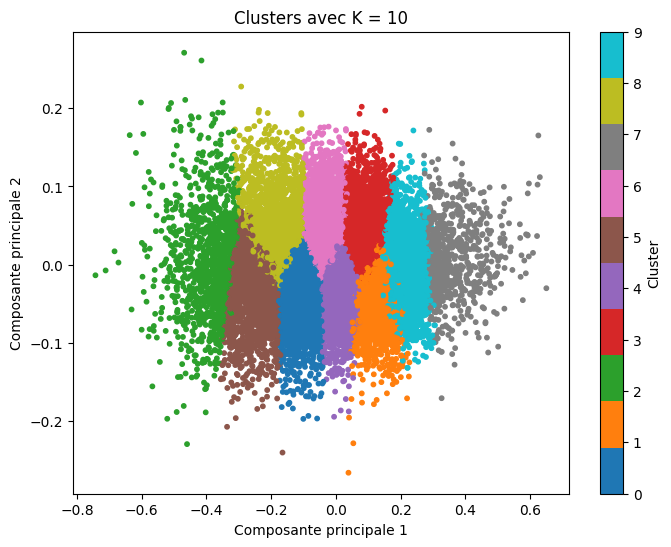

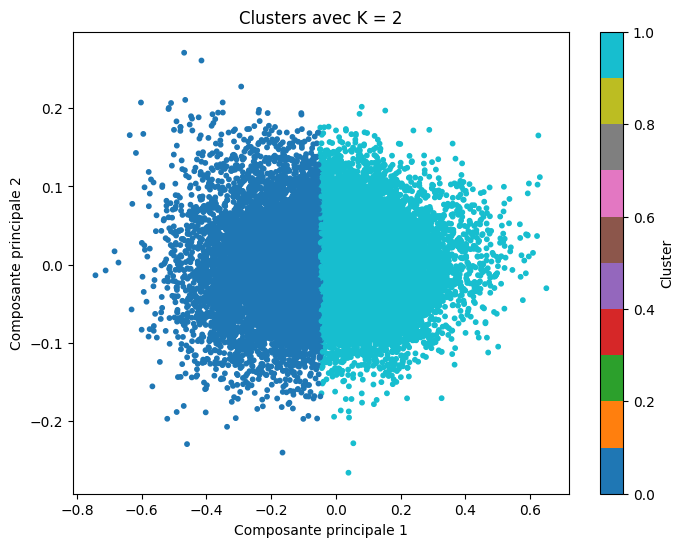

In [30]:


# KMeans pour K = 10
kmeans_10 = KMeans(n_clusters=10, random_state=42).fit(X)
clusters_10 = kmeans_10.labels_

# KMeans pour K = 2
kmeans_2 = KMeans(n_clusters=2, random_state=42).fit(X)
clusters_2 = kmeans_2.labels_

# Réduction de dimension avec PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)  # Projetion des données en 2D

# Visualisation des clusters
def plot_clusters(X_pca, clusters, k, title):
    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='tab10', s=10)
    plt.title(f"Clusters avec K = {k}")
    plt.xlabel("Composante principale 1")
    plt.ylabel("Composante principale 2")
    plt.colorbar(label="Cluster")
    plt.show()

# Visualisation pour K = 10
plot_clusters(X_pca, clusters_10, k=10, title="Clusters pour K = 10 (Optimal overlap)")

# Visualisation pour K = 2
plot_clusters(X_pca, clusters_2, k=2, title="Clusters pour K = 2 (Optimal silhouette)")
